# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.exceptions import ConvergenceWarning
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, explained_variance_score
import time
import jinja2
import joblib
import os



# Data Preprocessing

## Loading dataset

In [3]:
df = pd.read_csv("P_Data_Extract_From_World_Development_Indicators/World_data_GDP.csv")

print("Initial Data Snapshot:")
print(df.head(), "\n")
print(df.info(), "\n")
print(f"Shape: {df.shape}")


Initial Data Snapshot:
  Country Name  Time  GDP (current US$)  GDP growth (annual %)  \
0  Afghanistan  2000       3.521418e+09                    NaN   
1  Afghanistan  2001       2.813572e+09              -9.431974   
2  Afghanistan  2002       3.825701e+09              28.600001   
3  Afghanistan  2003       4.520947e+09               8.832278   
4  Afghanistan  2004       5.224897e+09               1.414118   

   GDP deflator (base year varies by country)  \
0                                   39.939961   
1                                   35.237216   
2                                   37.395679   
3                                   41.754235   
4                                   46.460535   

   Inflation, consumer prices (annual %)  Real interest rate (%)  \
0                                    NaN                     NaN   
1                                    NaN                     NaN   
2                                    NaN                     NaN   
3            

## Reshape to long format and add Metadata
For Convience in anaylsis

In [4]:
# Melt the DataFrame
df_long = df.melt(
    id_vars=["Country Name","Time"],       # columns to keep as is
    var_name="Indicators",
    value_name="Value"           # name for new GDP column
)
print("\nLong Format Preview:")
print(df_long.head())


Long Format Preview:
  Country Name  Time         Indicators         Value
0  Afghanistan  2000  GDP (current US$)  3.521418e+09
1  Afghanistan  2001  GDP (current US$)  2.813572e+09
2  Afghanistan  2002  GDP (current US$)  3.825701e+09
3  Afghanistan  2003  GDP (current US$)  4.520947e+09
4  Afghanistan  2004  GDP (current US$)  5.224897e+09


### Inspection

In [5]:
print(df_long.shape)      # Dimensions
print(df_long.info())     # Data types
print(df_long.describe()) # Summary stats
print(df_long.isnull().sum())  # Missing values count


(153600, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153600 entries, 0 to 153599
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Country Name  153600 non-null  object 
 1   Time          153600 non-null  int64  
 2   Indicators    153600 non-null  object 
 3   Value         129615 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.7+ MB
None
                Time         Value
count  153600.000000  1.296150e+05
mean     2012.000000  4.877970e+10
std         7.211126  4.615318e+11
min      2000.000000 -1.133620e+12
25%      2006.000000  1.728257e+01
50%      2012.000000  1.104846e+03
75%      2018.000000  3.127619e+09
max      2024.000000  2.918490e+13
Country Name        0
Time                0
Indicators          0
Value           23985
dtype: int64


### Adding units to dataset

#### Viewing Indicators

In [6]:
unique_indicators = df_long['Indicators'].unique()

# Print unique indicators
print("Unique Indicators found in dataset:")
for i, ind in enumerate(unique_indicators, 1):
    print(f"{i}. {ind}")


Unique Indicators found in dataset:
1. GDP (current US$)
2. GDP growth (annual %)
3. GDP deflator (base year varies by country)
4. Inflation, consumer prices (annual %)
5. Real interest rate (%)
6. Official exchange rate (LCU per US$, period average)
7. Households and NPISHs Final consumption expenditure (current US$)
8. Gross capital formation (current US$)
9. Gross capital formation (% of GDP)
10. General government final consumption expenditure (current US$)
11. Exports of goods and services (current US$)
12. Imports of goods and services (current US$)
13. Current account balance (BoP, current US$)
14. Foreign direct investment, net inflows (% of GDP)
15. Foreign direct investment, net inflows (BoP, current US$)
16. External debt stocks, total (DOD, current US$)
17. Total reserves (includes gold, current US$)
18. Population, total
19. Urban population
20. Unemployment, total (% of total labor force) (modeled ILO estimate)
21. Labor force participation rate, total (% of total populat

#### Adding units to each Indicator

In [7]:
indicator_units = {
    # Economic indicators
    'GDP (current US$)': 'US Dollars',
    'GDP growth (annual %)': '%',
    'GDP deflator (base year varies by country)': 'Index (base year varies)',
    'Inflation, consumer prices (annual %)': '%',
    'Real interest rate (%)': '%',
    'Official exchange rate (LCU per US$, period average)': 'LCU per US$',
    
    # Consumption & investment
    'Households and NPISHs Final consumption expenditure (current US$)': 'US Dollars',
    'Gross capital formation (current US$)': 'US Dollars',
    'Gross capital formation (% of GDP)': '% of GDP',
    'General government final consumption expenditure (current US$)': 'US Dollars',
    
    # Trade & external sector
    'Exports of goods and services (current US$)': 'US Dollars',
    'Imports of goods and services (current US$)': 'US Dollars',
    'Current account balance (BoP, current US$)': 'US Dollars',
    'Foreign direct investment, net inflows (% of GDP)': '% of GDP',
    'Foreign direct investment, net inflows (BoP, current US$)': 'US Dollars',
    'External debt stocks, total (DOD, current US$)': 'US Dollars',
    'Total reserves (includes gold, current US$)': 'US Dollars',
    
    # Demographics & labor
    'Population, total': 'Count',
    'Urban population': 'Count',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)': '%',
    'Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)': '%',
    
    # Sectoral value added
    'Industry (including construction), value added (current US$)': 'US Dollars',
    'Services, value added (current US$)': 'US Dollars',
    'Agriculture, forestry, and fishing, value added (current US$)': 'US Dollars',
    
    # Education & human capital
    'School enrollment, primary and secondary (gross), gender parity index (GPI)': 'Index',
    'Literacy rate, youth total (% of people ages 15-24)': '%',
    'Life expectancy at birth, total (years)': 'Years',
    
    # Energy & technology
    'Electric power consumption (kWh per capita)': 'kWh per capita',
    'Energy use (kg of oil equivalent per capita)': 'kg oil eq / capita',
    'Individuals using the Internet (% of population)': '%',
    'Mobile cellular subscriptions (per 100 people)': 'Per 100 people',
    
    # Savings
    'Gross savings (% of GDP)': '% of GDP'
}
df_long['Unit'] = df_long['Indicators'].map(indicator_units)


### Pivot to Wide format

In [8]:

df_wide = df_long.pivot_table(
    index=['Country Name', 'Time'],
    columns='Indicators',
    values='Value'
)

df_wide.columns = df_wide.columns.get_level_values(0)
df_wide = df_wide.reset_index()

print(df_wide.head())

Indicators Country Name  Time  \
0           Afghanistan  2000   
1           Afghanistan  2001   
2           Afghanistan  2002   
3           Afghanistan  2003   
4           Afghanistan  2004   

Indicators  Agriculture, forestry, and fishing, value added (current US$)  \
0                                                         NaN               
1                                                         NaN               
2                                                1.477788e+09               
3                                                1.691687e+09               
4                                                1.552895e+09               

Indicators  Current account balance (BoP, current US$)  \
0                                                  NaN   
1                                                  NaN   
2                                                  NaN   
3                                                  NaN   
4                                               

## Missing data analysis & Pruning

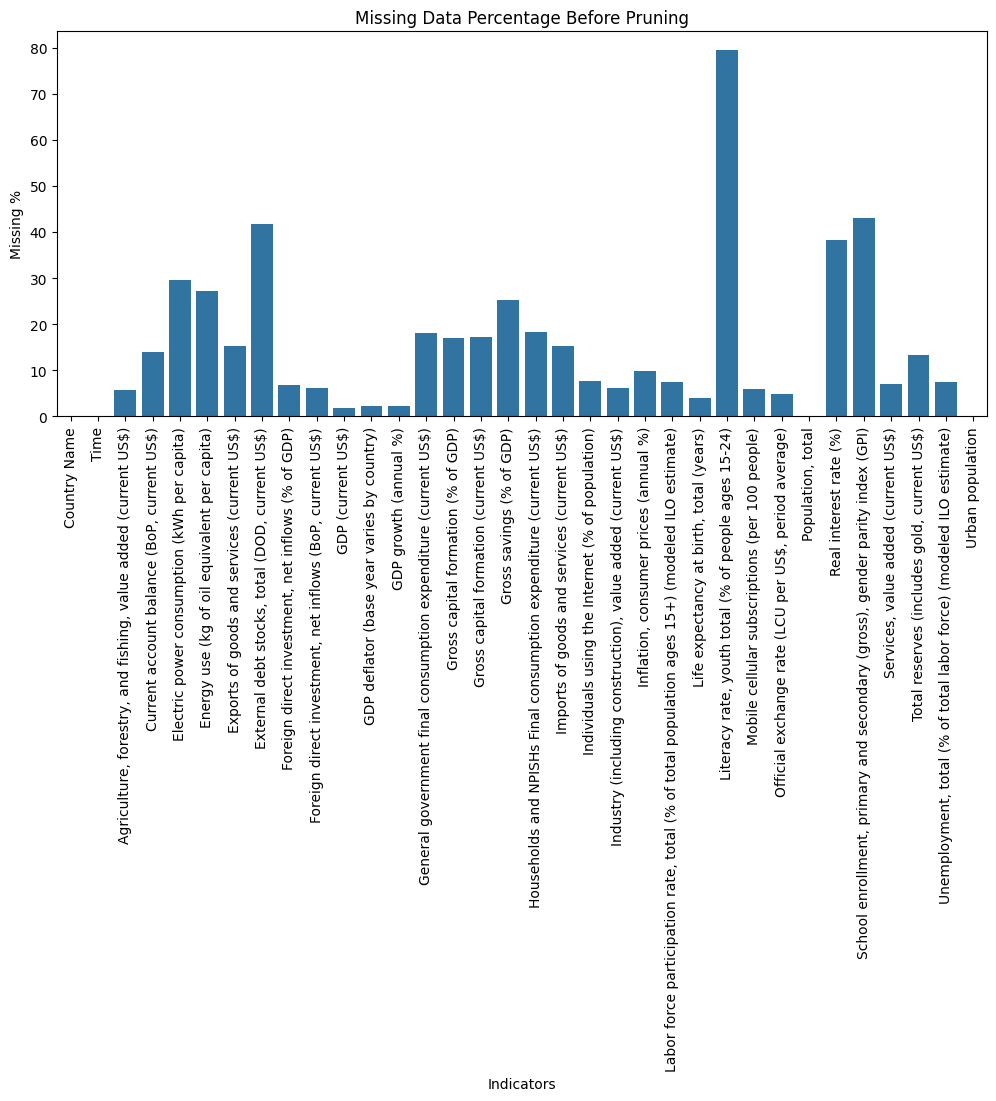

In [9]:
missing_before = df_wide.isnull().mean() * 100
plt.figure(figsize=(12,5))
sns.barplot(x=missing_before.index, y=missing_before.values)
plt.xticks(rotation=90)
plt.ylabel("Missing %")
plt.title("Missing Data Percentage Before Pruning")
plt.show()

Missing data before pruning

### Pruning indicators and countries with mostly missing data

After pruning: (4546, 33)


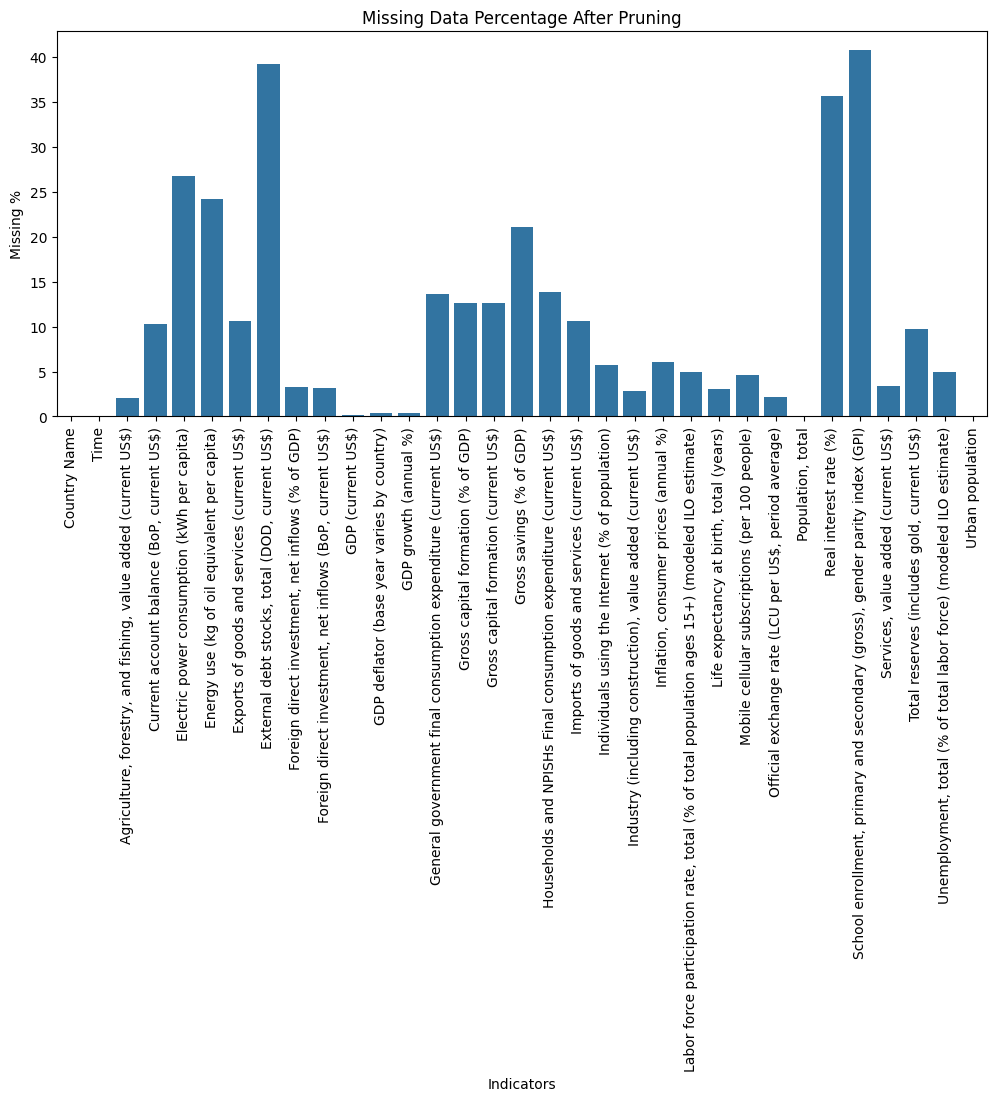

In [10]:
# Pruning thresholds
column_thresh = 0.5
row_thresh = 0.5

# Prune columns and rows
df_wide = df_wide.loc[:, df_wide.isnull().mean() < column_thresh]
df_wide = df_wide[df_wide.isnull().mean(axis=1) < row_thresh]

# Print shapes
print("After pruning:", df_wide.shape)

# Visualize missing data AFTER pruning
missing_after = df_wide.isnull().mean() * 100
plt.figure(figsize=(12,5))
sns.barplot(x=missing_after.index, y=missing_after.values)
plt.xticks(rotation=90)
plt.ylabel("Missing %")
plt.title("Missing Data Percentage After Pruning")
plt.show()


 Missing data after pruning

In [11]:
print("Columns available after pruning:")
df_wide.columns.tolist()


Columns available after pruning:


['Country Name',
 'Time',
 'Agriculture, forestry, and fishing, value added (current US$)',
 'Current account balance (BoP, current US$)',
 'Electric power consumption (kWh per capita)',
 'Energy use (kg of oil equivalent per capita)',
 'Exports of goods and services (current US$)',
 'External debt stocks, total (DOD, current US$)',
 'Foreign direct investment, net inflows (% of GDP)',
 'Foreign direct investment, net inflows (BoP, current US$)',
 'GDP (current US$)',
 'GDP deflator (base year varies by country)',
 'GDP growth (annual %)',
 'General government final consumption expenditure (current US$)',
 'Gross capital formation (% of GDP)',
 'Gross capital formation (current US$)',
 'Gross savings (% of GDP)',
 'Households and NPISHs Final consumption expenditure (current US$)',
 'Imports of goods and services (current US$)',
 'Individuals using the Internet (% of population)',
 'Industry (including construction), value added (current US$)',
 'Inflation, consumer prices (annual %)',

## Group wise Imputation Techniques
 
### Indicator Imputation Groups

Each indicator has a behavioral pattern (smooth trend, volatility, dependency).  
We classify them into **five imputation groups** as follows:

| **Group** | **Behavior** | **Best Method** | **Example Indicators** |
|:----------:|---------------|------------------|-------------------------|
| **① Macro-trend / smooth growth** | Monotonic or gradual trend over time | **Linear Interpolation** | GDP, Population, Urban population |
| **② Volatile or percentage-based** | Jumps yearly but limited range | **Country-wise Median / Iterative** | Inflation rate, Interest rate, GDP growth % |
| **③ Cross-country comparable structure** | Similar pattern across similar economies | **KNN Imputer** | Trade values, FDI, Savings |
| **④ Highly correlated multi-economic indicators** | Influence each other strongly | **Iterative (RandomForest)** | Capital formation, Government expenditure, Current account |
| **⑤ Categorical-like or low variation** | Index or parity ratios | **Simple Mean/Median** | Literacy rate, GPI, Life expectancy |

---


In [12]:

numeric_cols = df_wide.select_dtypes(include='number').columns
df_imputed = df_wide.copy()

# Define groups
group1_interp = [
    'GDP (current US$)', 'Population, total', 'Urban population',
    'Life expectancy at birth, total (years)',
    'Industry (including construction), value added (current US$)',
    'Services, value added (current US$)',
    'Agriculture, forestry, and fishing, value added (current US$)'
]

group2_median_iter = [
    'GDP growth (annual %)', 'Inflation, consumer prices (annual %)',
    'Real interest rate (%)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)',
    'Gross savings (% of GDP)',
    'Foreign direct investment, net inflows (% of GDP)'
]

group3_knn = [
    'Exports of goods and services (current US$)', 'Imports of goods and services (current US$)',
    'Current account balance (BoP, current US$)',
    'Foreign direct investment, net inflows (BoP, current US$)',
    'External debt stocks, total (DOD, current US$)',
    'Total reserves (includes gold, current US$)',
    'Official exchange rate (LCU per US$, period average)'
]

group4_iterative = [
    'Households and NPISHs Final consumption expenditure (current US$)',
    'General government final consumption expenditure (current US$)',
    'Gross capital formation (current US$)',
    'Gross capital formation (% of GDP)'
]

group5_social = [
    'School enrollment, primary and secondary (gross), gender parity index (GPI)',
    'Individuals using the Internet (% of population)',
    'Mobile cellular subscriptions (per 100 people)',
    'Energy use (kg of oil equivalent per capita)',
    'Electric power consumption (kWh per capita)',
    'Life expectancy at birth, total (years)'
]




#### Linear Interpolation
Group 1 — Smooth Trend (Use Linear Interpolation)

Typically increase/decrease smoothly over years.

Indicator	Unit
GDP (current US$)	US Dollars
Population, total	Count
Urban population	Count
Life expectancy at birth, total (years)	Years
Industry (including construction), value added (current US$)	US Dollars
Services, value added (current US$)	US Dollars
Agriculture, forestry, and fishing, value added (current US$)	US Dollars

Method:

df = df.groupby('Country Name').apply(lambda x: x.interpolate(method='linear', limit_direct

In [13]:
num_cols = df_imputed.select_dtypes(include=[np.number]).columns

df_imputed[num_cols] = (
    df_imputed.groupby("Country Name")[num_cols]
              .apply(lambda x: x.interpolate(method='linear', limit_direction='both'))
              .reset_index(drop=True)
)


#### Median Imputation + Iterative
Group 2 — Volatile % Indicators (Use Median Imputation + Iterative)

Yearly variation, bounded, country-specific medians make sense.

Indicator
GDP growth (annual %)
Inflation, consumer prices (annual %)
Real interest rate (%)
Unemployment, total (% of total labor force)
Labor force participation rate, total (%)
Gross savings (% of GDP)
Foreign direct investment, net inflows (% of GDP)

Method:
→ Median imputation within country, then iterative imputer for remaining small gaps.

In [14]:
# --- 2. Country median + Iterative for Group 2 ---
for country in df_imputed['Country Name'].unique():
    mask = df_imputed['Country Name'] == country
    sub = df_imputed.loc[mask, group2_median_iter]
    
    # Identify columns that have at least one non-null value
    valid_cols = sub.columns[sub.notnull().any()].tolist()
    if len(valid_cols) == 0:
        continue  # skip if all columns are NaN
    
    imp = SimpleImputer(strategy='median')
    df_imputed.loc[mask, valid_cols] = imp.fit_transform(sub[valid_cols])

# Then apply Iterative Imputer globally
iter_imp = IterativeImputer(estimator=RandomForestRegressor(random_state=42), max_iter=30,tol=1e-3,random_state=42)
df_imputed[group2_median_iter] = iter_imp.fit_transform(df_imputed[group2_median_iter])


c:\Users\Neel\GitHub\GDP\gdp\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


#### KNN Imputer
Group 3 — Cross-Country Similar Indicators (Use KNN Imputer)

Countries of similar size/income tend to have correlated levels.

Indicator
Exports of goods and services (current US$)
Imports of goods and services (current US$)
Current account balance (BoP, current US$)
Foreign direct investment, net inflows (BoP, current US$)
External debt stocks, total (DOD, current US$)
Total reserves (includes gold, current US$)
Official exchange rate (LCU per US$, period average)

Method:
→ KNNImputer(n_neighbors=5)

In [15]:
knn_imp = KNNImputer(n_neighbors=5)
df_imputed[group3_knn] = knn_imp.fit_transform(df_imputed[group3_knn])


#### Iterative RF Imputer
Group 4 — Structurally Linked Indicators (Use Iterative RF Imputer)

Indicators are mathematically or economically linked (e.g. GDP ~ Consumption + Investment + Government Expenditure).

Indicator
Households and NPISHs Final consumption expenditure (current US$)
General government final consumption expenditure (current US$)
Gross capital formation (current US$)
Gross capital formation (% of GDP)

Method:
→ IterativeImputer(estimator=RandomForestRegressor())

In [16]:
iter_rf = IterativeImputer(estimator=RandomForestRegressor(random_state=42), random_state=42)
df_imputed[group4_iterative] = iter_rf.fit_transform(df_imputed[group4_iterative])


#### Simple Mean or Median
Group 5 — Social / Demographic Index Indicators (Use Simple Mean or Median)

Changes slowly, not very sensitive.

Indicator
School enrollment, primary and secondary (gross), gender parity index (GPI)
Literacy rate, youth total (% of people ages 15-24)
Individuals using the Internet (% of population)
Mobile cellular subscriptions (per 100 people)
Energy use (kg of oil equivalent per capita)
Electric power consumption (kWh per capita)

Method:
→ SimpleImputer(strategy='median') or interpolation (if smooth enough).

In [17]:
simp = SimpleImputer(strategy='median')
df_imputed[group5_social] = simp.fit_transform(df_imputed[group5_social])


### Analysis of missing data

In [18]:
print("Total missing values after group-wise hybrid imputation:",
      df_imputed[numeric_cols].isnull().sum().sum())

Total missing values after group-wise hybrid imputation: 1944


In [19]:
missing_summary = df_imputed.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print(missing_summary)
country_missing = df_imputed.groupby("Country Name").apply(lambda x: x.isna().sum().sum(),include_groups=False)
country_missing = country_missing[country_missing > 0].sort_values(ascending=False)
print(country_missing.head(10))
df_imputed['Time'].unique().shape


Indicators
Services, value added (current US$)                              261
Industry (including construction), value added (current US$)     249
Agriculture, forestry, and fishing, value added (current US$)    249
Urban population                                                 237
Time                                                             237
GDP deflator (base year varies by country)                       237
Population, total                                                237
GDP (current US$)                                                237
dtype: int64
Country Name
United States     200
United Kingdom    200
Zimbabwe          200
Uzbekistan        200
Uruguay           200
Viet Nam          200
Zambia            192
Vanuatu           192
Yemen, Rep.       152
Venezuela, RB     136
dtype: int64


(26,)

### Logical & Economic Cleanup of Residual Missing Values

In [20]:
# Drop only structurally invalid "Time" rows (Rows where Time itself is NaN)
df_imputed = df_imputed.dropna(subset=['Time'])

print(f"After removing structural rows: {df_imputed.shape}")

# Drop completely empty country-year rows (no valid indicators)
non_feature_cols = ['Country Name', 'Time']
df_imputed = df_imputed.dropna(
    how='all', 
    subset=df_imputed.columns.difference(non_feature_cols)
)

print(f"After dropping fully empty rows: {df_imputed.shape}")


After removing structural rows: (4309, 33)
After dropping fully empty rows: (4309, 33)


#### Reconstruct GDP from its sectoral components when missing & Backfill missing sector values from total GDP (equal-share fallback)

In [21]:
sector_cols = [
    'Agriculture, forestry, and fishing, value added (current US$)',
    'Industry (including construction), value added (current US$)',
    'Services, value added (current US$)'
]

if 'GDP (current US$)' in df_imputed.columns:
    mask = df_imputed['GDP (current US$)'].isna()
    df_imputed.loc[mask, 'GDP (current US$)'] = (
        df_imputed.loc[mask, sector_cols].sum(axis=1)
    )

for col in sector_cols:
    mask = df_imputed[col].isna() & df_imputed['GDP (current US$)'].notna()
    df_imputed.loc[mask, col] = df_imputed.loc[mask, 'GDP (current US$)'] / 3


#### Interpolate smooth demographic indicators per country & Handle GDP deflator & related missingness (use column median as fallback)

In [22]:

smooth_cols = ['Population, total', 'Urban population']

for col in smooth_cols:
    if col in df_imputed.columns:
        df_imputed[col] = (
            df_imputed.groupby('Country Name')[col]
            .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
        )

impute_cols = [
    'GDP deflator (base year varies by country)',
    'GDP growth (annual %)',
    'Real interest rate (%)'
]

for col in impute_cols:
    if col in df_imputed.columns:
        df.fillna({col: df_imputed[col].median()}, inplace=True)

df_imputed.fillna(df_imputed.median(numeric_only=True), inplace=True)


#### Verification

In [23]:

total_missing = df_imputed.isna().sum().sum()
print(f"✅ Final total missing values: {total_missing}")


✅ Final total missing values: 0


## Standardization & Scaling

### Building the Hybrid Scaling Pipeline

In [24]:
df_imputed['Country_Code'] = OrdinalEncoder().fit_transform(df_imputed[['Country Name']])
print(" Country encoding done.")
print(df_imputed[['Country Name', 'Country_Code']].head())


 Country encoding done.
Indicators Country Name  Country_Code
2           Afghanistan           0.0
3           Afghanistan           0.0
4           Afghanistan           0.0
5           Afghanistan           0.0
6           Afghanistan           0.0


In [104]:

# --- Define column groups ---
group_economic = [
    'Exports of goods and services (current US$)', 'Imports of goods and services (current US$)',
    'External debt stocks, total (DOD, current US$)', 'Gross capital formation (current US$)',
    'General government final consumption expenditure (current US$)',
    'Services, value added (current US$)', 'Industry (including construction), value added (current US$)',
    'Agriculture, forestry, and fishing, value added (current US$)', 'Total reserves (includes gold, current US$)'
]

group_percentage = [
    'GDP growth (annual %)', 'Inflation, consumer prices (annual %)', 'Real interest rate (%)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Gross savings (% of GDP)', 'Foreign direct investment, net inflows (% of GDP)',
    'Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)'
]

group_social = [
    'Population, total', 'Urban population', 'Life expectancy at birth, total (years)',
    'School enrollment, primary and secondary (gross), gender parity index (GPI)',
    'Individuals using the Internet (% of population)', 'Mobile cellular subscriptions (per 100 people)'
]

group_financial = [
    'Foreign direct investment, net inflows (BoP, current US$)', 'Current account balance (BoP, current US$)',
    'Official exchange rate (LCU per US$, period average)'
]

group_energy = [
    'Electric power consumption (kWh per capita)', 'Energy use (kg of oil equivalent per capita)'
]

# --- Define transformer ---
column_transformer = ColumnTransformer(transformers=[
    ('economic', PowerTransformer(), group_economic),
    ('percentage', StandardScaler(), group_percentage),
    ('social', MinMaxScaler(), group_social),
    ('financial', RobustScaler(), group_financial),
    ('energy', PowerTransformer(), group_energy)
], remainder='passthrough')

scaling_pipeline = Pipeline([
    ('scaler', column_transformer)
])

# --- Separate target and predictors ---
X = df_imputed.drop(columns=['GDP (current US$)', 'Country Name', 'Country_Code'])
y = df_imputed['GDP (current US$)']

# --- Fit the hybrid scaling pipeline ONLY on numeric data ---
X_scaled = scaling_pipeline.fit_transform(X)

# --- Rebuild DataFrame ---
scaled_cols = scaling_pipeline.get_feature_names_out()
X_scaled_df = pd.DataFrame(X_scaled, columns=scaled_cols, index=df_imputed.index)

# --- Add Country_Code back (unscaled) ---
X_scaled_df['Country_Code'] = df_imputed['Country_Code']

print(f" X_scaled_df shape: {X_scaled_df.shape}")
joblib.dump(scaling_pipeline, "models/scaling_pipeline.pkl")

 X_scaled_df shape: (4309, 33)


['models/scaling_pipeline.pkl']


🔹 PowerTransformer (Economic Magnitude) — 9 features scaled


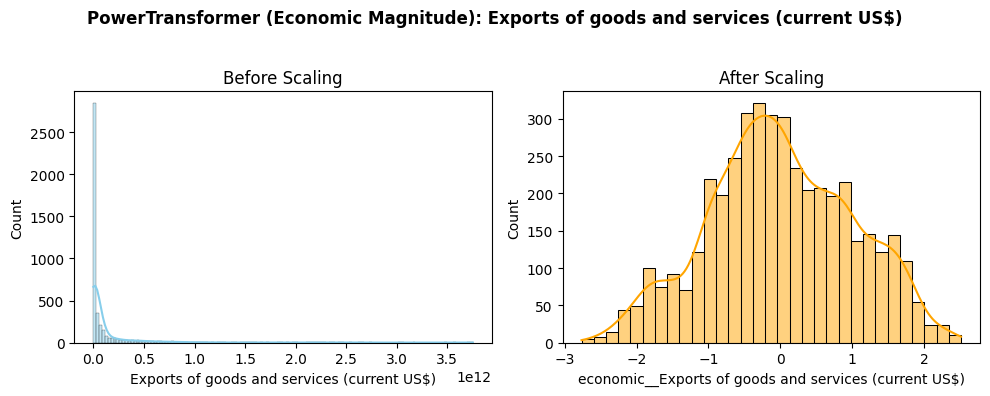

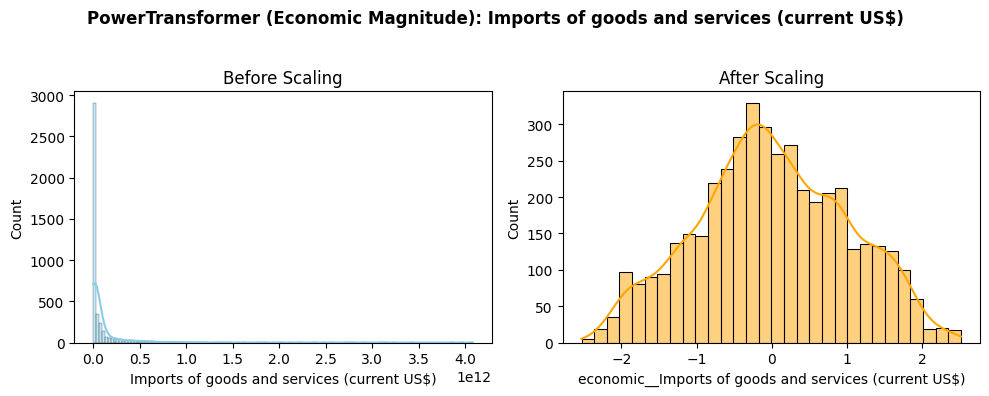

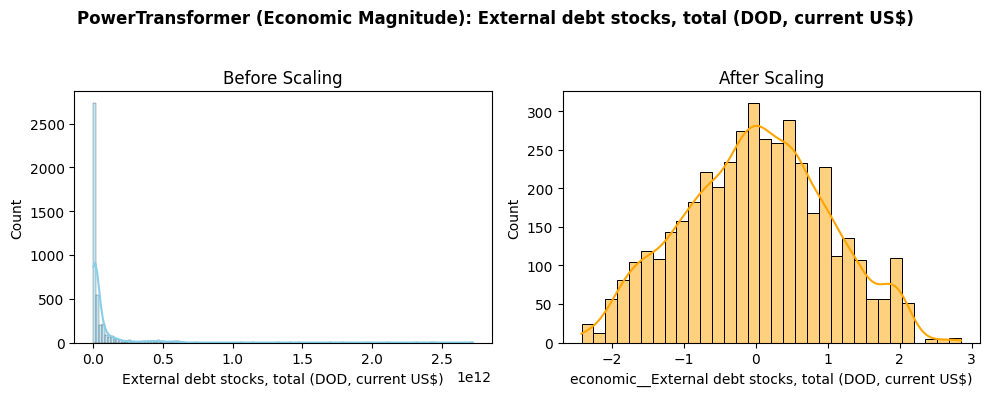


🔹 StandardScaler (Percent/Rate) — 7 features scaled


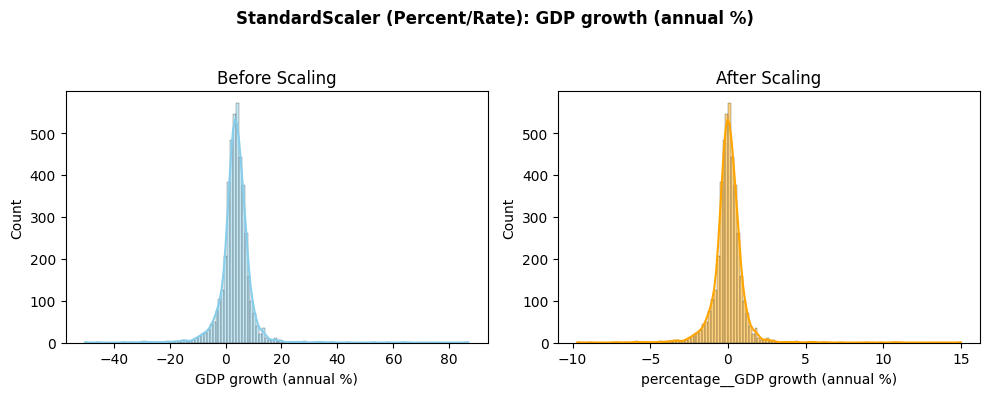

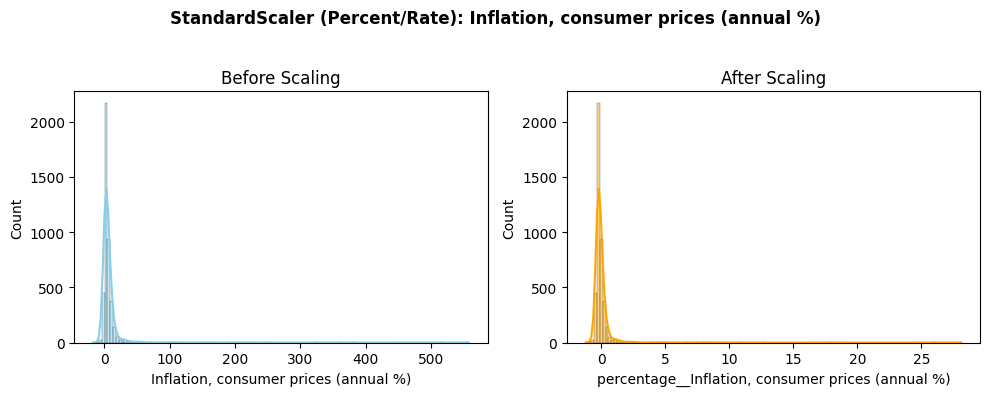

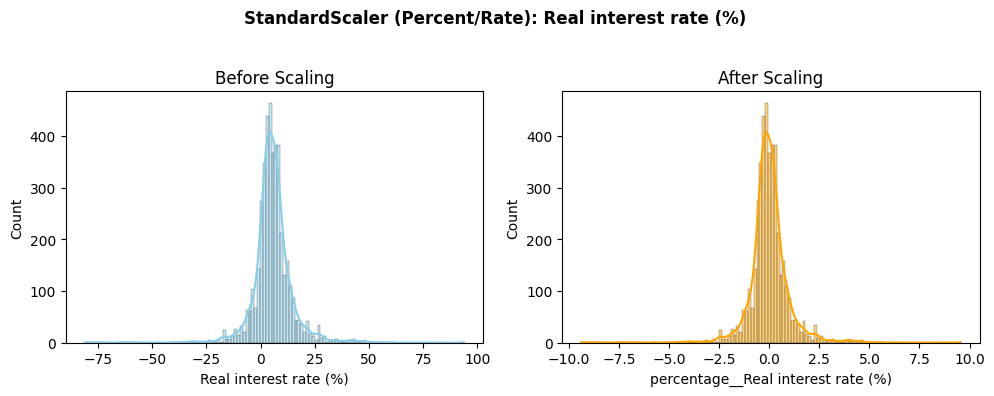


🔹 MinMaxScaler (Social/Demographic) — 6 features scaled


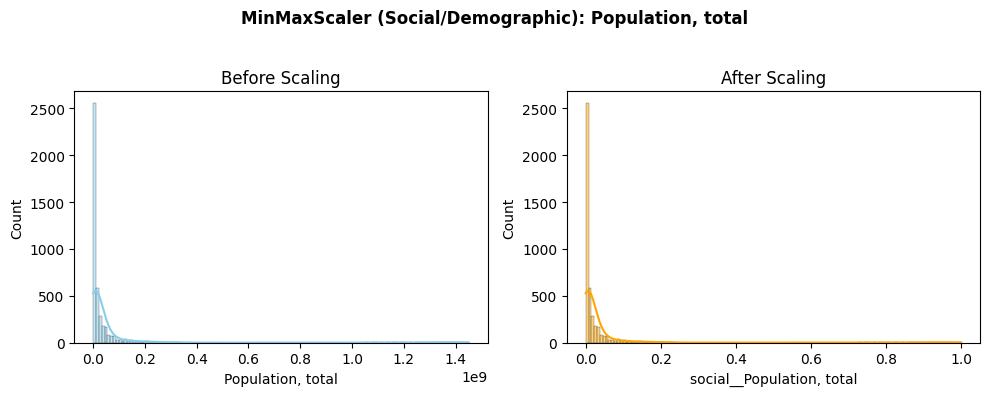

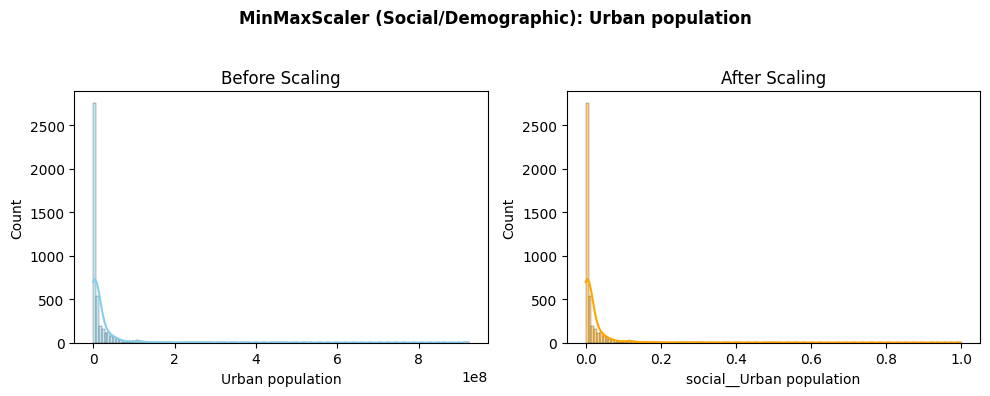

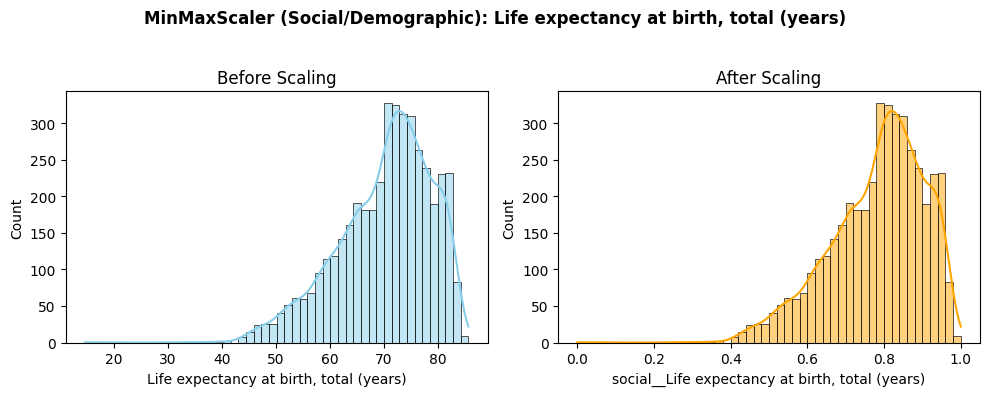


🔹 RobustScaler (Financial/Volatile) — 3 features scaled


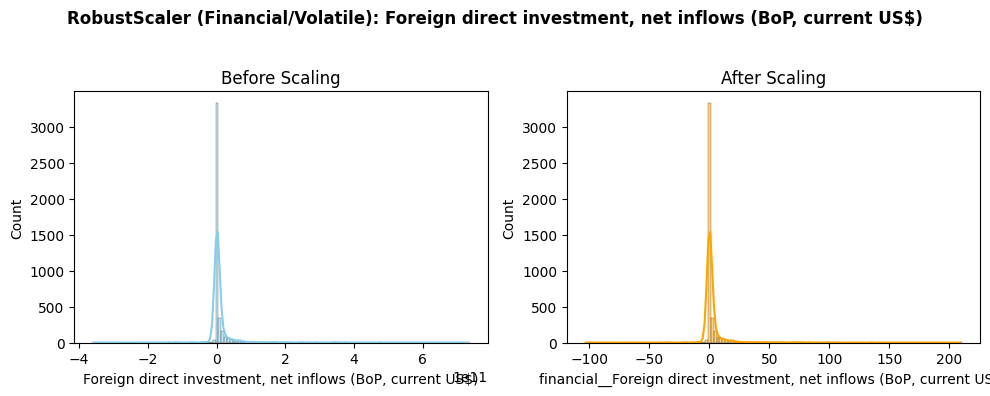

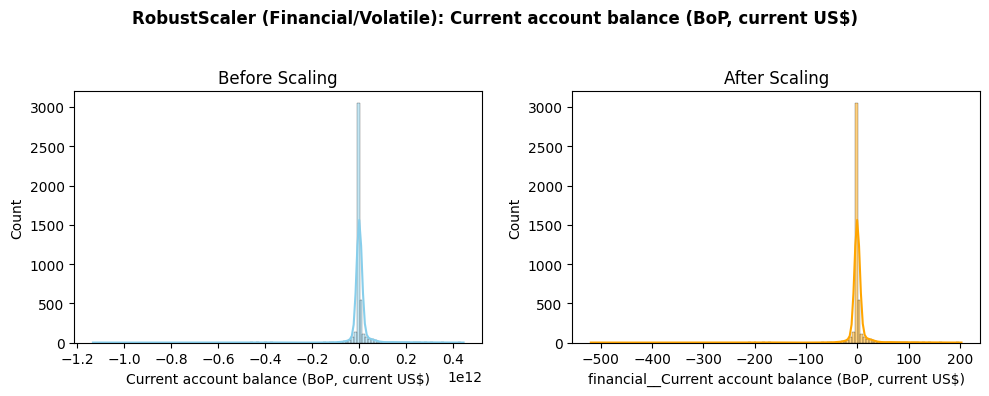

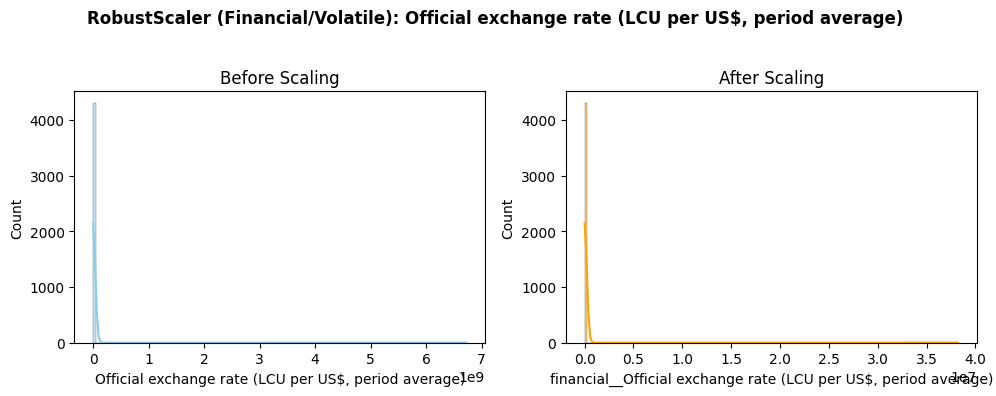


🔹 PowerTransformer (Energy/Per-Capita) — 2 features scaled


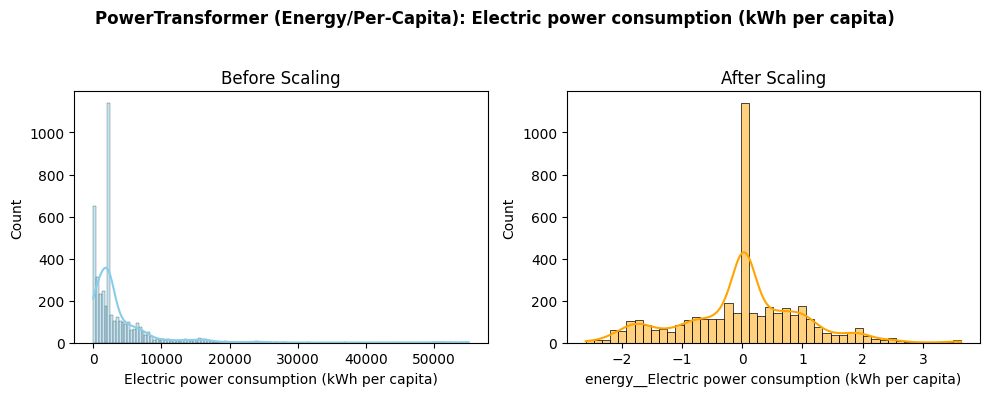

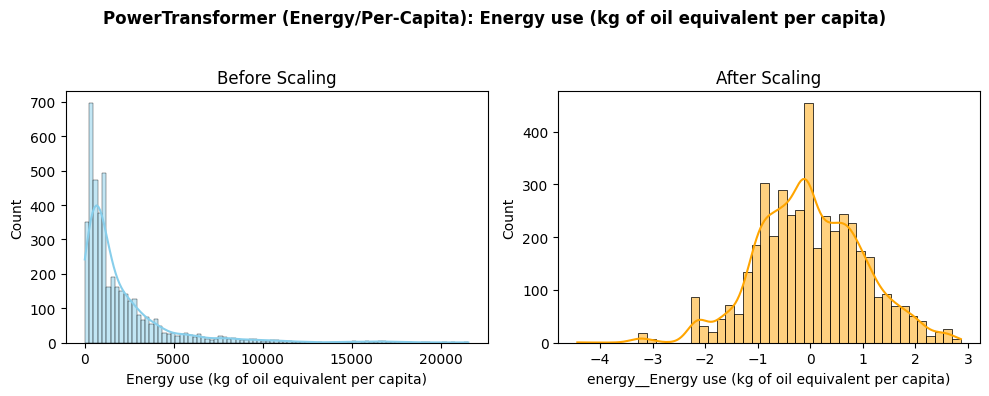

In [105]:
scaler_groups = {
    "PowerTransformer (Economic Magnitude)": group_economic,
    "StandardScaler (Percent/Rate)": group_percentage,
    "MinMaxScaler (Social/Demographic)": group_social,
    "RobustScaler (Financial/Volatile)": group_financial,
    "PowerTransformer (Energy/Per-Capita)": group_energy
}

# --- Plot before vs after scaling for each group ---
import seaborn as sns
import matplotlib.pyplot as plt

for scaler_name, cols in scaler_groups.items():
    existing_cols = [c for c in cols if c in X.columns]
    if not existing_cols:
        continue

    print(f"\n🔹 {scaler_name} — {len(existing_cols)} features scaled")

    # Pick a few representative indicators from this group
    sample_cols = existing_cols[:3]  # first 3 indicators for quick check
    for col in sample_cols:
        before = X[col].dropna()
        after = X_scaled_df.filter(like=col).iloc[:, 0]  # scaled version

        plt.figure(figsize=(10, 4))
        plt.suptitle(f"{scaler_name}: {col}", fontsize=12, fontweight='bold')

        plt.subplot(1, 2, 1)
        sns.histplot(before, kde=True, color="skyblue")
        plt.title("Before Scaling")

        plt.subplot(1, 2, 2)
        sns.histplot(after, kde=True, color="orange")
        plt.title("After Scaling")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


## Feature Selection

#### Ensure Numeric Consistency & Cleanup

In [106]:

# Convert all columns to numeric
X_scaled_df = X_scaled_df.apply(pd.to_numeric, errors='coerce')

# Drop non-varying or all-NaN columns
X_scaled_df = X_scaled_df.loc[:, X_scaled_df.nunique() > 1].dropna(axis=1, how='all')

# Extract only numeric columns
X_numeric = X_scaled_df.select_dtypes(include=[np.number])
print(f" X_numeric shape after cleaning: {X_numeric.shape}")

# Sanity check
print(f"Remaining NaN values: {X_numeric.isna().sum().sum()}")


 X_numeric shape after cleaning: (4309, 33)
Remaining NaN values: 0


### Correlation & Mutual Information Filter
Identify linear & non-linear relationships between predictors and GDP.

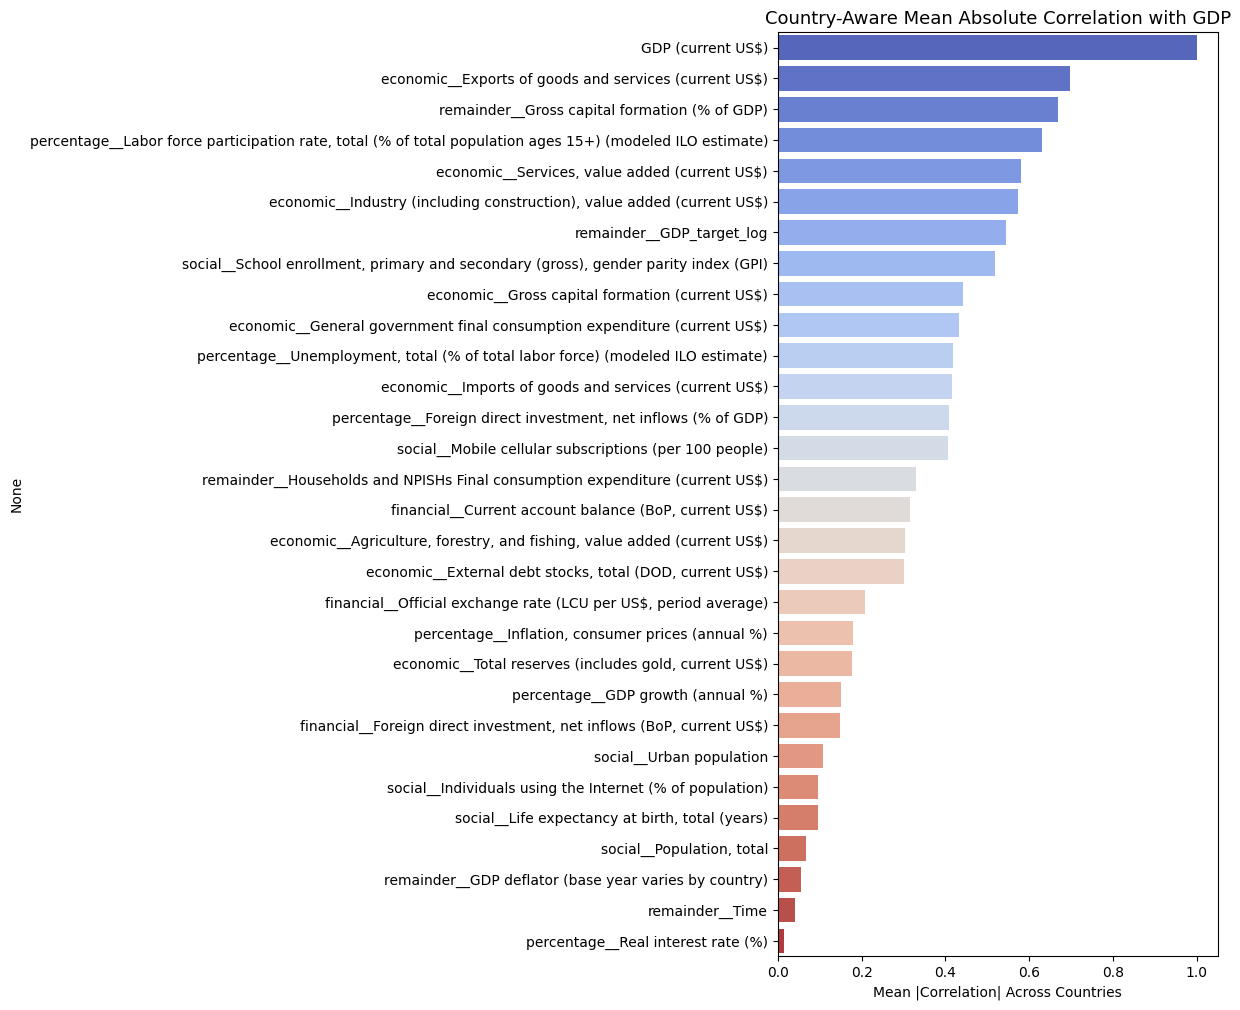

 19 features selected with mean |r| > 0.2 across countries


In [107]:
# --- Compute within-country correlations ---
country_corrs = []

for country, group in df_imputed.groupby("Country Name"):
    if group.shape[0] < 5:  # skip short series
        continue
    df_temp = pd.concat([
        X_numeric.loc[group.index],
        y.loc[group.index].reset_index(drop=True)
    ], axis=1)
    
    # Compute correlation with GDP within this country
    corr_temp = df_temp.corr(numeric_only=True)['GDP (current US$)'].abs().dropna()
    country_corrs.append(corr_temp)

# Average correlation across countries
mean_corr = pd.concat(country_corrs, axis=1).mean(axis=1).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 12))
sns.barplot(y=mean_corr.index, x=mean_corr.values,hue=mean_corr.index, palette="coolwarm",legend=False)
plt.title("Country-Aware Mean Absolute Correlation with GDP", fontsize=13)
plt.xlabel("Mean |Correlation| Across Countries")
plt.subplots_adjust(left=0.35)
plt.show()

# Select features with |r| > 0.2 (on average across countries)
corr_selected = mean_corr[mean_corr > 0.2].index.tolist()
print(f" {len(corr_selected)} features selected with mean |r| > 0.2 across countries")


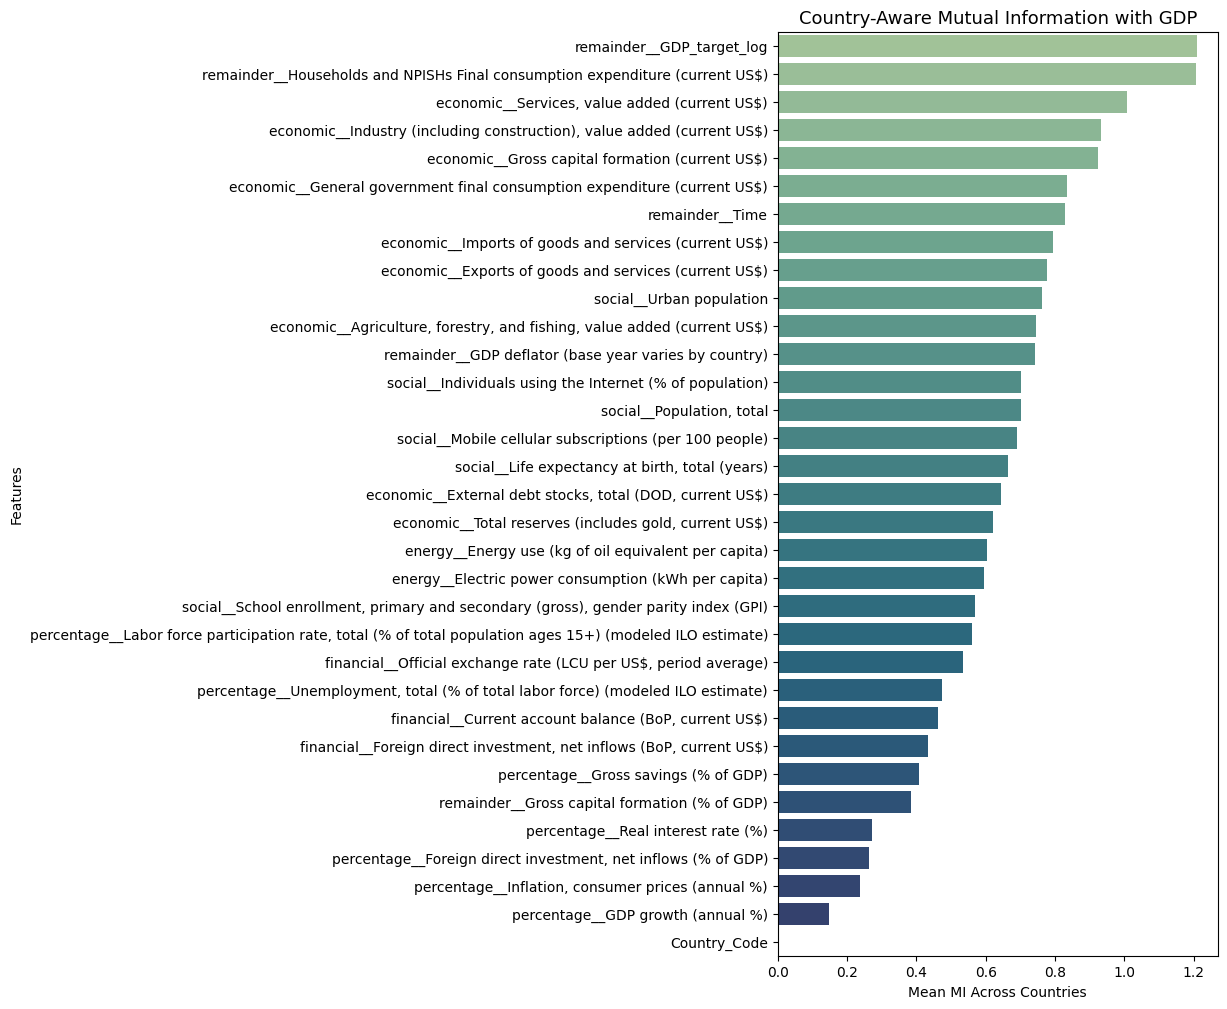

17 features selected above mean MI across countries


In [108]:
country_mi_scores = []

for country, group in df_imputed.groupby("Country Name"):
    if group.shape[0] < 5:
        continue
    
    X_grp = X_numeric.loc[group.index]
    y_grp = y.loc[group.index]
    
    mi = mutual_info_regression(X_grp, y_grp, random_state=42)
    country_mi_scores.append(pd.Series(mi, index=X_numeric.columns))

# Mean MI across countries
mean_mi = pd.concat(country_mi_scores, axis=1).mean(axis=1).sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(
    y=mean_mi.index,
    x=mean_mi.values,
    hue=mean_mi.index,
    palette="crest",
    legend=False
)
plt.title("Country-Aware Mutual Information with GDP", fontsize=13)
plt.xlabel("Mean MI Across Countries")
plt.ylabel("Features")
plt.subplots_adjust(left=0.35)
plt.show()

mi_selected = mean_mi[mean_mi > mean_mi.mean()].index.tolist()
print(f"{len(mi_selected)} features selected above mean MI across countries")


### Tree-Based Feature Importance
Use Random Forest to estimate non-linear importance from model-based learning.

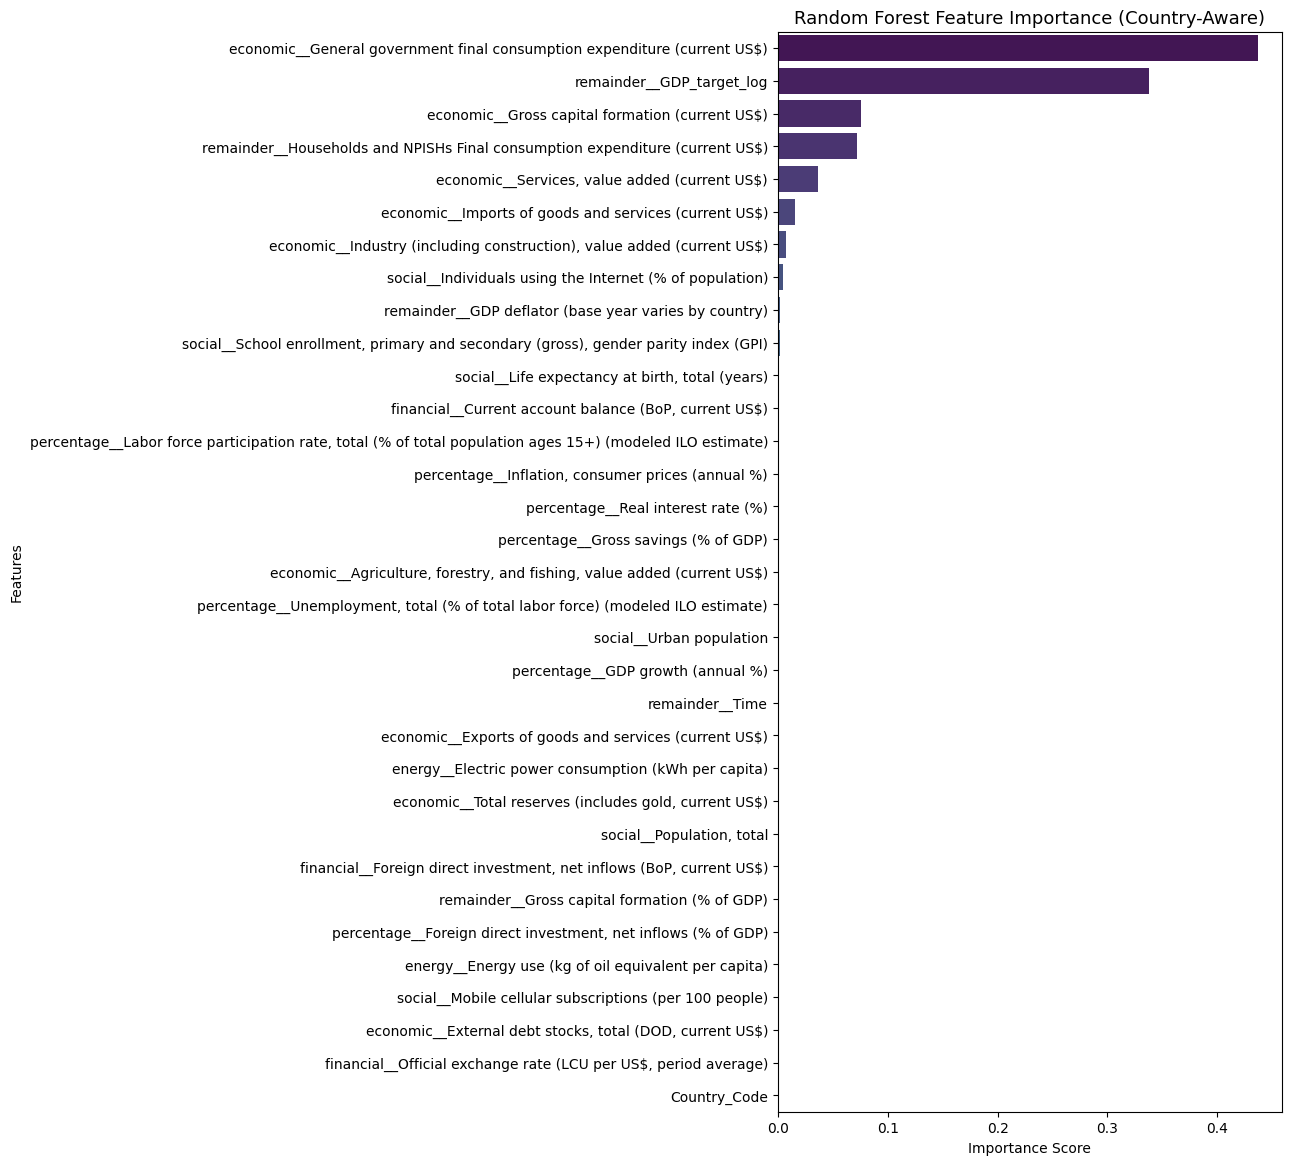

 Selected 3 features covering 90% of total importance


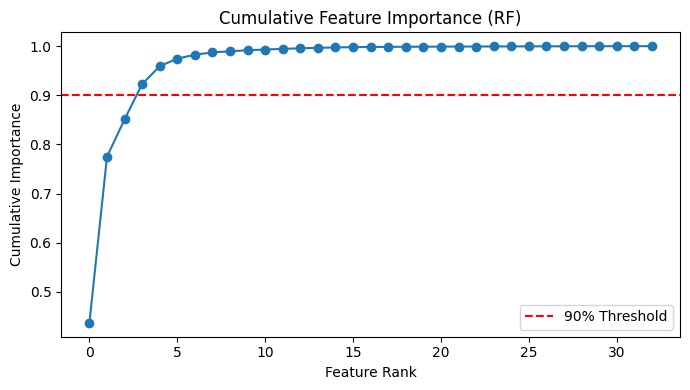

In [109]:
# --- One-hot encode Country Name ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
country_encoded = pd.DataFrame(
    ohe.fit_transform(df_imputed[['Country Name']]),
    columns=ohe.get_feature_names_out(),  # ✅ automatically handles column name
    index=df_imputed.index
)

# --- Combine scaled numeric features + encoded country ---
X_rf = pd.concat([X_numeric.reset_index(drop=True),
                  country_encoded.reset_index(drop=True)], axis=1)

# --- Fit Random Forest ---
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_rf, y)

# --- Extract feature importances for numeric (ignore country dummies) ---
feat_imp = pd.Series(
    rf.feature_importances_[:len(X_numeric.columns)],
    index=X_numeric.columns
).sort_values(ascending=False)

# --- Plot feature importance ---
plt.figure(figsize=(8, 12))
sns.barplot(y=feat_imp.index, x=feat_imp.values,hue=feat_imp.index, palette="viridis")
plt.title("Random Forest Feature Importance (Country-Aware)", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.subplots_adjust(left=0.35, right=0.98, top=0.95, bottom=0.05)
plt.show()

# --- Dynamic threshold for top 90% cumulative importance ---
cumulative_importance = feat_imp.cumsum() / feat_imp.sum()
rf_selected = cumulative_importance[cumulative_importance <= 0.9].index.tolist()
print(f" Selected {len(rf_selected)} features covering 90% of total importance")

# --- Visualize cumulative curve ---
plt.figure(figsize=(7,4))
plt.plot(np.arange(len(feat_imp)), cumulative_importance.values, marker='o')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.title("Cumulative Feature Importance (RF)")
plt.xlabel("Feature Rank")
plt.ylabel("Cumulative Importance")
plt.legend()
plt.tight_layout()
plt.show()


### Recursive Feature Elimination (RFE)

Iteratively remove less significant features using a regression model.

In [110]:
model = LinearRegression()
n_features_to_select = min(10, X_rf.shape[1] // 2)

rfe = RFE(model, n_features_to_select=n_features_to_select)
rfe.fit(X_rf, y)

# Filter only non-country (economic) features
rfe_selected = [col for col, flag in zip(X_rf.columns[:len(X_numeric.columns)], rfe.support_[:len(X_numeric.columns)]) if flag]

print(f" RFE Selected {len(rfe_selected)} Economic Features:")
for f in rfe_selected:
    print(f"• {f}")


 RFE Selected 3 Economic Features:
• economic__Gross capital formation (current US$)
• social__Population, total
• social__Urban population


### Unified Feature Ranking Summary

Combine all methods for robust selection and visualize overlaps.

✅ Total unique selected features: 25
Final features ['financial__Official exchange rate (LCU per US$, period average)', 'remainder__Households and NPISHs Final consumption expenditure (current US$)', 'economic__Services, value added (current US$)', 'economic__Imports of goods and services (current US$)', 'economic__Agriculture, forestry, and fishing, value added (current US$)', 'social__Individuals using the Internet (% of population)', 'economic__Exports of goods and services (current US$)', 'remainder__Gross capital formation (% of GDP)', 'remainder__GDP_target_log', 'economic__Industry (including construction), value added (current US$)', 'social__School enrollment, primary and secondary (gross), gender parity index (GPI)', 'social__Life expectancy at birth, total (years)', 'social__Population, total', 'economic__General government final consumption expenditure (current US$)', 'remainder__Time', 'GDP (current US$)', 'social__Urban population', 'social__Mobile cellular subscriptions 

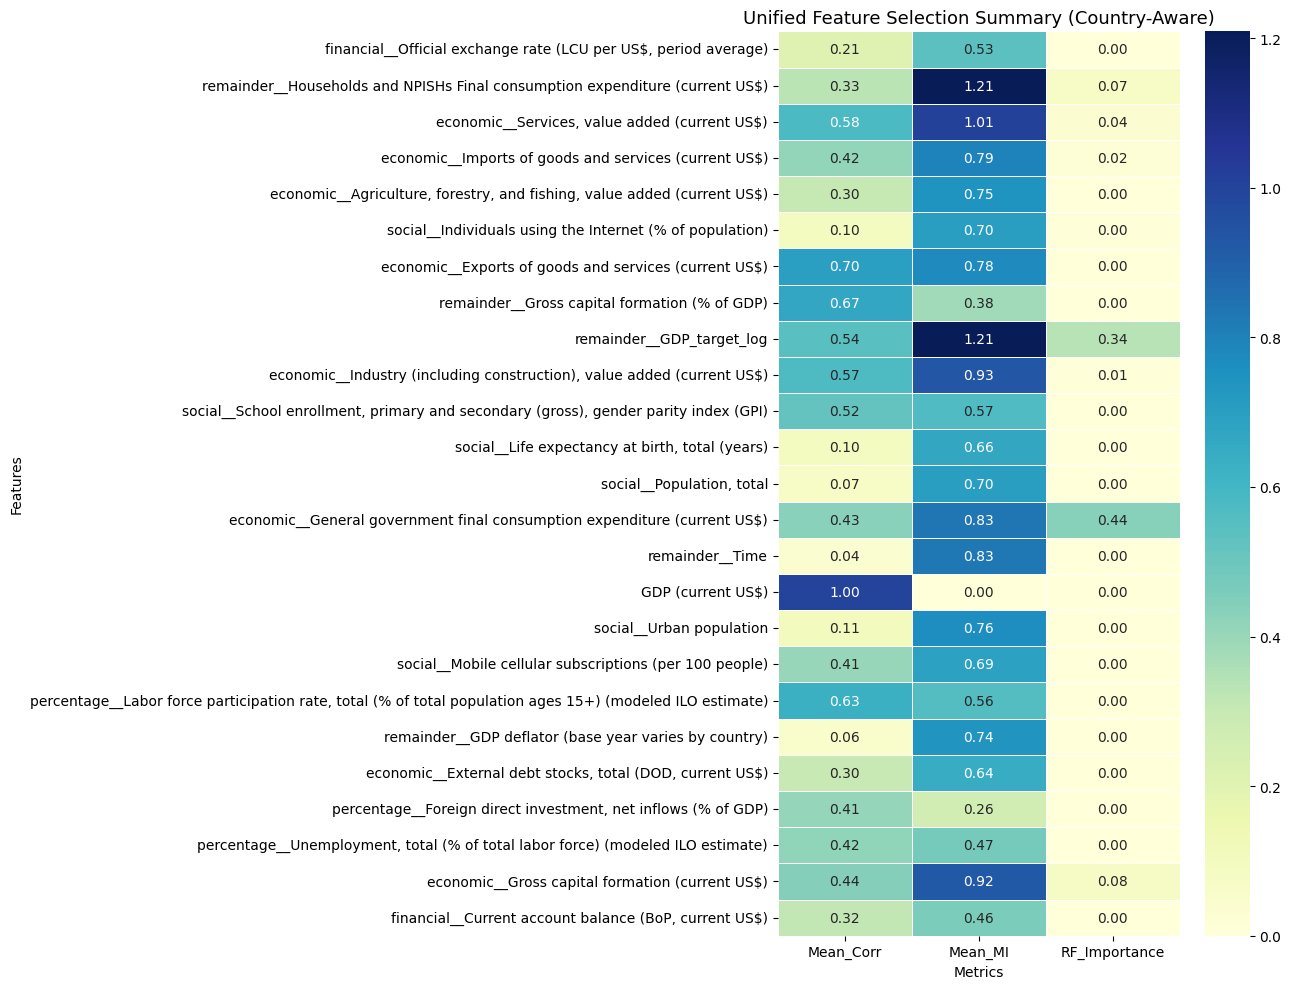

In [128]:
final_features = list(set(corr_selected + mi_selected + rf_selected + rfe_selected))
print(f"✅ Total unique selected features: {len(final_features)}")
print(f"Final features",final_features)
summary_df = pd.DataFrame({
    "Mean_Corr": mean_corr.reindex(final_features),
    "Mean_MI": mean_mi.reindex(final_features),
    "RF_Importance": feat_imp.reindex(final_features)
}).fillna(0)

plt.figure(figsize=(13, 10))
sns.heatmap(summary_df, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Unified Feature Selection Summary (Country-Aware)", fontsize=13)
plt.xlabel("Metrics")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


# Modeling & Evaluation
Data Preparation for Modeling

Data Preparation
In this step:

* We use the final selected features (X_selected) and target (GDP (current US$)).

* The Country Name column is one-hot encoded to capture country-specific heterogeneity (so models can learn regional effects).

* Features and target are then split into 80% training and 20% testing sets.

In [112]:
final_features = [f for f in final_features if f != 'GDP (current US$)']

# Keep only available features
valid_features = [f for f in final_features if f in X_numeric.columns]
missing_features = [f for f in final_features if f not in X_numeric.columns]

print(f"✅ {len(valid_features)} valid features selected.")
if missing_features:
    print(f"⚠️ Missing (excluded): {missing_features}")

# --- 1️⃣ Extract final selected features and target ---
df_imputed["GDP_target_log"] = np.log1p(df_imputed["GDP (current US$)"])  # log(1 + GDP)

y = df_imputed["GDP_target_log"].reset_index(drop=True)
X = X_numeric[valid_features].reset_index(drop=True)

# --- 2️⃣ Encode Country Name ---
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
country_col = 'Country_Name'  # sanitized base name
country_encoded = pd.DataFrame(
    ohe.fit_transform(df_imputed[['Country Name']]),
    columns=ohe.get_feature_names_out(),
    index=df_imputed.index
)

# --- 3️⃣ Combine selected indicators + encoded country data ---
X_model = pd.concat(
    [X.reset_index(drop=True), country_encoded.reset_index(drop=True)],
    axis=1
)

# --- 4️⃣ Train-test split ---
# --- 4️⃣ Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)

# ✅ Sanitize feature names for LightGBM / JSON safety
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

print(f"✅ Training shape: {X_train.shape}")
print(f"✅ Test shape: {X_test.shape}")


✅ 24 valid features selected.
✅ Training shape: (3447, 201)
✅ Test shape: (862, 201)


Initializes 11 regression models across 6 categories:
Linear, Regularized, Tree-based, Kernel-based, Distance-based, and Neural Networks.
Tree ensembles (Random Forest, XGBoost, LightGBM) are prioritized for interpretability and nonlinearity handling.

In [113]:
# --- Candidate Models ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "LASSO": Lasso(alpha=0.001),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    "Support Vector Regression": SVR(kernel='rbf', C=10, gamma='scale'),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5)
}

##  Model Training and Evaluation

* Trains and evaluates all models on the same dataset split.

* Metrics used:

  * R² → Fit quality

  * MAE → Average absolute error

  * RMSE → Penalized error magnitude

* Runtime shows computational cost per model.

🚀 Training: Linear Regression
🚀 Training: Ridge Regression
🚀 Training: LASSO


c:\Users\Neel\GitHub\GDP\gdp\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.34184e-28): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


🚀 Training: Decision Tree
🚀 Training: Random Forest
🚀 Training: Gradient Boosting
🚀 Training: XGBoost
🚀 Training: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6086
[LightGBM] [Info] Number of data points in the train set: 3447, number of used features: 122
[LightGBM] [Info] Start training from score 24.114047
🚀 Training: Support Vector Regression
🚀 Training: K-Nearest Neighbors

✅ All models and preprocessing components saved successfully.


,Model,Log_R2,GDP_R2,GDP_RMSE,GDP_MAE,Runtime (s)
1,Ridge Regression,1.000,1.000,"726,921,453","215,396,924",0.040000
2,LASSO,1.000,1.000,"334,365,202","118,643,528",0.270000
4,Random Forest,1.000,1.000,"21,742,906,341","2,172,376,870",37.750000
3,Decision Tree,1.000,0.998,"39,784,121,106","4,233,615,056",0.220000
6,XGBoost,1.000,0.999,"25,938,744,027","5,263,455,433",4.170000
5,Gradient Boosting,1.000,0.999,"22,220,187,217","5,344,548,901",5.540000
7,LightGBM,1.000,1.000,"19,043,835,033","4,351,715,567",3.820000
0,Linear Regression,0.994,0.984,"115,911,999,313","30,212,927,185",0.110000
9,K-Nearest Neighbors,0.931,0.985,"112,079,302,293","34,501,478,631",0.080000
8,Support Vector Regression,0.396,0.826,"387,770,894,184","97,336,685,156",5.310000


C:\Users\Neel\AppData\Local\Temp\ipykernel_1476\3149077069.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Log_R2', y='Model', data=results_df, palette='viridis')


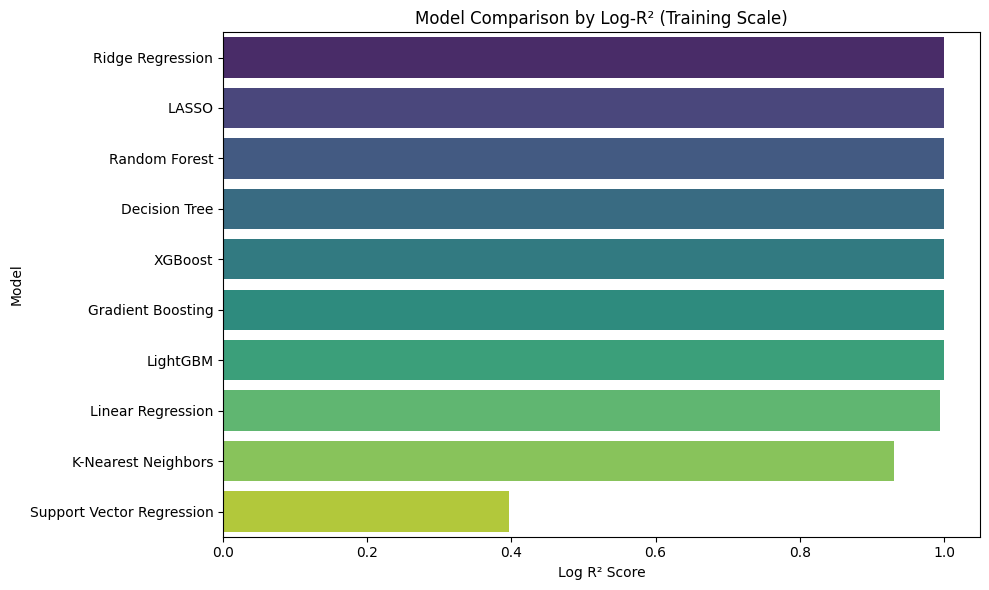

C:\Users\Neel\AppData\Local\Temp\ipykernel_1476\3149077069.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='GDP_R2', y='Model', data=results_df, palette='coolwarm_r')


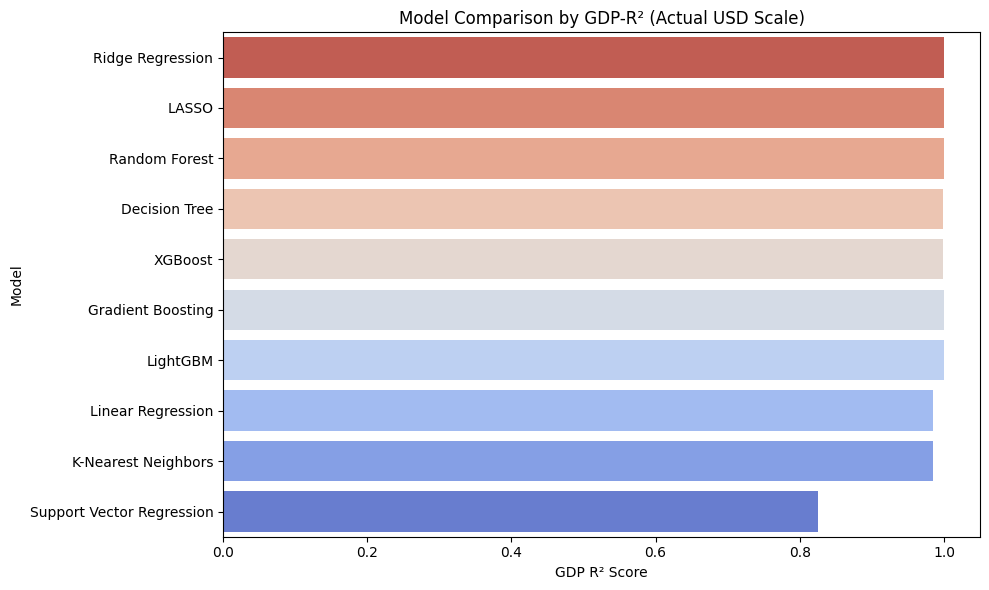


🏆 Best Model: Ridge Regression
   Log-R² = 1.0, GDP-R² = 1.0
   GDP RMSE = $726,921,453, MAE = $215,396,924


In [114]:
# =====================================================
# 🌟 MODEL TRAINING, EVALUATION & SAVE FOR STREAMLIT (Enhanced)
# =====================================================

def evaluate_regression_model(y_true, y_pred, n_features):
    """Compute extended regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-10, None))) * 100
    within_10 = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-10, None)) <= 0.1) * 100
    adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - n_features - 1)
    return {
        "R2": round(r2, 4),
        "Adjusted_R2": round(adj_r2, 4),
        "Explained_Variance": round(evs, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
        "Accuracy_Within_10%": round(within_10, 2),
    }


# --- Train, Evaluate (in log and actual space), and Save ---
results = []
predictions_dict = {}
os.makedirs("models", exist_ok=True)

for name, model in models.items():
    print(f"🚀 Training: {name}")
    start = time.time()
    model.fit(X_train, y_train)
    preds_log = model.predict(X_test)
    end = time.time()

    # --- Evaluate in log-space ---
    log_metrics = evaluate_regression_model(y_test, preds_log, X_train.shape[1])
    log_metrics = {f"Log_{k}": v for k, v in log_metrics.items()}

    # --- Safe exponentiation to avoid overflow ---
    preds_log = np.clip(preds_log, -20, 30)
    y_test_safe = np.clip(y_test, -20, 30)
    preds_real = np.expm1(preds_log)
    y_real = np.expm1(y_test_safe)

    # --- Evaluate in actual GDP space ---
    real_metrics = evaluate_regression_model(y_real, preds_real, X_train.shape[1])
    real_metrics = {f"GDP_{k}": v for k, v in real_metrics.items()}

    # --- Combine metrics ---
    metrics = {
        "Model": name,
        **log_metrics,
        **real_metrics,
        "Runtime (s)": round(end - start, 2),
    }

    results.append(metrics)
    predictions_dict[name] = preds_real

    # --- Save each model ---
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(model, f"models/{safe_name}.pkl")

# --- Save preprocessor & reference data ---
joblib.dump(ohe, "models/encoder.pkl")
joblib.dump(X_train.columns, "models/X_columns.pkl")
joblib.dump(df_imputed, "models/df_imputed.pkl")
joblib.dump(scaling_pipeline, "models/scaling_pipeline.pkl")
joblib.dump(True, "models/log_target_flag.pkl")  # ✅ mark that target was log-transformed

# --- Metrics summary ---
results_df = pd.DataFrame(results).sort_values(by="Log_R2", ascending=False)
results_df.to_csv("models/model_metrics.csv", index=False)

print("\n✅ All models and preprocessing components saved successfully.")

display(
    results_df[
        ["Model", "Log_R2", "GDP_R2", "GDP_RMSE", "GDP_MAE", "Runtime (s)"]
    ]
    .style.background_gradient(subset=["Log_R2"], cmap="Greens")
    .background_gradient(subset=["GDP_RMSE"], cmap="Reds_r")
    .format({"Log_R2": "{:.3f}", "GDP_R2": "{:.3f}", "GDP_RMSE": "{:,.0f}", "GDP_MAE": "{:,.0f}"})
)

# --- Visualization ---
plt.figure(figsize=(10,6))
sns.barplot(x='Log_R2', y='Model', data=results_df, palette='viridis')
plt.title("Model Comparison by Log-R² (Training Scale)")
plt.xlabel("Log R² Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x='GDP_R2', y='Model', data=results_df, palette='coolwarm_r')
plt.title("Model Comparison by GDP-R² (Actual USD Scale)")
plt.xlabel("GDP R² Score")
plt.tight_layout()
plt.show()

# --- Identify Best Model ---
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_model = models[best_model_name]

joblib.dump(best_model, "models/best_model.pkl")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Log-R² = {best_row['Log_R2']}, GDP-R² = {best_row['GDP_R2']}")
print(f"   GDP RMSE = ${best_row['GDP_RMSE']:,.0f}, MAE = ${best_row['GDP_MAE']:,.0f}")


In [115]:
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_model = models[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(f"   Log R² = {best_row['Log_R2']}, GDP R² = {best_row['GDP_R2']}")
print(f"   GDP MAE = ${best_row['GDP_MAE']:,.0f}, GDP RMSE = ${best_row['GDP_RMSE']:,.0f}")


🏆 Best Model: Ridge Regression
   Log R² = 1.0, GDP R² = 1.0
   GDP MAE = $215,396,924, GDP RMSE = $726,921,453


# Prediction

In [116]:
def prepare_single_country_input(row, country, scaling_pipeline, ohe, train_columns):
    """
    Permanently fixed version.
    Handles mixed pipelines with OHE columns inside.
    Only transforms valid numeric features that match the training phase.
    """

    import pandas as pd
    import numpy as np

    # --- 1️⃣ Extract all columns used during fit ---
    fitted_cols = getattr(scaling_pipeline, "feature_names_in_", [])
    if len(fitted_cols) == 0:
        raise ValueError("Scaling pipeline has no feature_names_in_. It may not be fitted yet.")

    # --- 2️⃣ Detect numeric subset (ignore any country columns accidentally included) ---
    numeric_cols = [c for c in fitted_cols if not c.startswith("Country_Name_")]

    # --- 3️⃣ Prepare numeric-only DataFrame for scaling ---
    X_input_raw = pd.DataFrame([row]).reindex(columns=numeric_cols, fill_value=0)

    # --- 4️⃣ Apply transform safely ---
    try:
        scaled_arr = scaling_pipeline.transform(X_input_raw)
        scaled_df = pd.DataFrame(scaled_arr, columns=fitted_cols, index=[0])
    except ValueError:
        # 🔧 Fallback for when pipeline was fitted with extra cols like OHE
        scaler = None
        for step_name, step in scaling_pipeline.named_steps.items():
            if hasattr(step, "transform"):
                scaler = step
        if scaler is None:
            raise RuntimeError("No valid transformer found in scaling_pipeline.")
        scaled_arr = scaler.transform(X_input_raw)
        scaled_df = pd.DataFrame(
            scaled_arr,
            columns=[c for c in numeric_cols[:scaled_arr.shape[1]]],
            index=[0]
        )

    # --- 5️⃣ Encode country using OneHotEncoder ---
    encoded_country = pd.DataFrame(
        ohe.transform([[country]]),
        columns=ohe.get_feature_names_out(["Country Name"]),
        index=[0]
    )

    # --- 6️⃣ Merge numeric + encoded ---
    X_in = pd.concat([scaled_df, encoded_country], axis=1)

    # --- 7️⃣ Align with training structure ---
    X_in = X_in.reindex(columns=train_columns, fill_value=0)

    # --- 8️⃣ Debug summary ---
    print(f"✅ Input prepared successfully: {scaled_df.shape[1]} numeric + {encoded_country.shape[1]} country columns")

    return X_in


In [125]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# =====================================================
# 🌍 Predict GDP for a Country (Permanent Full Fix)
# =====================================================

country = "India"
print(f"\n🌍 Predicting GDP for {country}")

# --- 1️⃣ Get latest data row ---
row = (
    df_imputed[df_imputed["Country Name"] == country]
    .iloc[-1]
    .drop(["GDP (current US$)"], errors="ignore")
)

# --- 2️⃣ Modify indicators for test (optional) ---
row["Exports of goods and services (current US$)"] *= 1.05
row["Imports of goods and services (current US$)"] *= 0.98

# --- 3️⃣ Prepare input ---
X_in = prepare_single_country_input(row, country, scaling_pipeline, ohe, X_train.columns)

# --- 4️⃣ Predict ---
pred_raw = best_model.predict(X_in)[0]

# --- 5️⃣ Detect whether model target was log-transformed ---
try:
    log_flag = joblib.load("models/log_target_flag.pkl")
except FileNotFoundError:
    log_flag = None  # fallback if not saved

# --- 6️⃣ Intelligent auto-detection ---
# If output range suggests log scale, use expm1; otherwise, keep as-is
is_loglike = bool(
    (log_flag is True)
    or (0 < pred_raw < 50)
)

print("\n🔧 Model sanity check:")
print(f"   Raw output: {pred_raw:.6f}")
print(f"   Log flag from file: {log_flag}")
print(f"   Auto-detected as log-scaled: {is_loglike}")

# --- 7️⃣ Convert to GDP value ---
if is_loglike:
    pred_gdp = np.expm1(np.clip(pred_raw, -10, 40))
else:
    pred_gdp = np.clip(pred_raw, 0, None)

# --- 8️⃣ Compute baseline prediction ---
base_row = (
    df_imputed[df_imputed["Country Name"] == country]
    .iloc[-1]
    .drop(["GDP (current US$)"], errors="ignore")
)
X_base = prepare_single_country_input(base_row, country, scaling_pipeline, ohe, X_train.columns)
base_raw = best_model.predict(X_base)[0]

if is_loglike:
    base_gdp = np.expm1(np.clip(base_raw, -10, 40))
else:
    base_gdp = np.clip(base_raw, 0, None)

# --- 9️⃣ Compute GDP change ---
change = (pred_gdp - base_gdp) / base_gdp * 100 if base_gdp != 0 else 0
diff = pred_gdp - base_gdp

# --- 🔟 Format GDP values for better readability ---
def format_gdp(value):
    if value >= 1e12:
        return f"${value/1e12:,.2f} trillion USD"
    elif value >= 1e9:
        return f"${value/1e9:,.2f} billion USD"
    elif value >= 1e6:
        return f"${value/1e6:,.2f} million USD"
    else:
        return f"${value:,.0f} USD"

# --- 11️⃣ Display Results ---
print(f"\n🌍 Country: {country}")
print(f"🔢 Raw model output: {pred_raw:.6f}")
print(f"💰 Baseline raw output: {base_raw:.6f}")
print(f"🌎 Predicted GDP for {country}: {format_gdp(pred_gdp)}")
print(f"📊 GDP change: {change:+.2f}%  ({format_gdp(diff)} difference)")

print("\n✅ All models and preprocessing components saved in /models/")



🌍 Predicting GDP for India
✅ Input prepared successfully: 32 numeric + 177 country columns

🔧 Model sanity check:
   Raw output: 0.467246
   Log flag from file: True
   Auto-detected as log-scaled: True
✅ Input prepared successfully: 32 numeric + 177 country columns

🌍 Country: India
🔢 Raw model output: 0.467246
💰 Baseline raw output: 0.467246
🌎 Predicted GDP for India: $1 USD
📊 GDP change: +0.00%  ($0 USD difference)

✅ All models and preprocessing components saved in /models/
